# Analysis and figures

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from analysis_scripts.us_analysis import *
from analysis_scripts.md_analysis import *
from analysis_scripts.gbsa_analysis import *
from analysis_scripts.docking_analysis import *

from analysis_scripts.plotstyle import set_rcparams
set_rcparams() # set plotting style

In [2]:
"""Defining constants"""

temperature = 300.0000 # K
boltzmann = 0.0019872041 # kcal/mol K
beta = 1.0/(boltzmann*temperature)
k_sep = 1000 # kcal/mol nm**-2
k_boresch = 100 # kcal/mol rad**2
k_rmsd = 500 # kcal/mol nm**-2|
r_star = 2.9 # Point in the bulk state
standard_volume = 1660 # angstroms^3
standard_volume_nm = standard_volume*0.001 # nm^3
radius_sphere = (3*standard_volume_nm/(4*np.pi))**(1.0/3.0) # radius of sphere whose volume is equal to the standard volume in nm

### Plotting a specific PMF

Specify the desired system:

In [ ]:
system = 'CRBN_len_CK1a'
stage = 'RMSD' # Choose 'RMSD', 'separation' or 'Boresch' 
dof = 'CRBN_len' # Choose None for separation stage
replicas = [1,2,3]

Applying RED: 100%|██████████| 17/17 [00:00<00:00, 60375.25it/s]


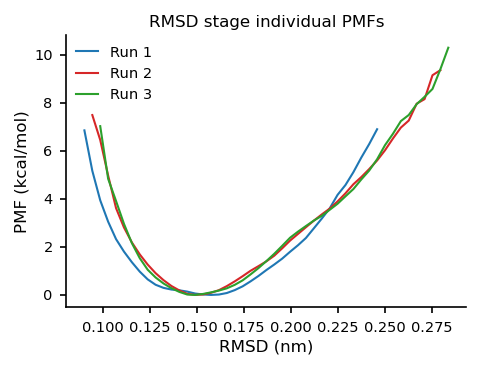

/home/btan/miniforge3/envs/openbiosim/lib/python3.11/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [4]:
# Run this cell

if stage == 'Boresch':
    equilibration = None # CV samples already truncated for Boresch US
    bins = 50 # WHAM number of bins
    k=k_boresch
else:
    equilibration = 'RED' # Use RED for separation and RMSD
    bins = 200
    k=k_sep

# Find upper and lower limit for WHAM
generate_metafile(system, stage, dof, equilibration, run_number=1, k_CV=k, plot=False)
resultspath = obtain_dirpath(system, stage, dof, equilibration, run_number=1)
CV_vals = [float(filename.split('.txt')[0]) for filename in os.listdir(resultspath) if filename.endswith('.txt') and filename not in ('pmf.txt', 'metafile.txt')]
upper_limit = np.max(CV_vals)
lower_limit = np.min(CV_vals)

# Convert to units of nm for RMSD US
if stage == 'RMSD':
    upper_limit = np.round(upper_limit*0.1, 5) + 0.1
    lower_limit = np.round(lower_limit*0.1, 5)
    bins = 100
    k=k_rmsd # Overwrite to RMSD force constant

wham_params = [lower_limit, upper_limit, bins, 1e-6, 300, 0]

for run_number in replicas:

    generate_metafile(system, stage, dof, equilibration, run_number, k_CV=k, plot=False)
    perform_WHAM(wham_params, system, stage, dof, equilibration, run_number)
    x, pmf = obtain_PMF(system, stage, dof, equilibration, run_number, plot=False)

x_av, pmf_av, err = obtain_av_PMF(replicas, system, stage, dof, equilibration, plot_indiv=True, plot_av=False)

### Histograms of samples for a specific US simulation

Specify the system below:

In [29]:
system = 'CRBN_len_CK1a'
stage = 'Boresch' # Choose 'RMSD', 'separation' or 'Boresch' 
dof = 'phiA' # Choose None for separation stage
run_number = 3 # Specify the replica

/home/btan/Documents/MG_US/CRBN_len_CK1a/US/Boresch/results/phiA/run3/


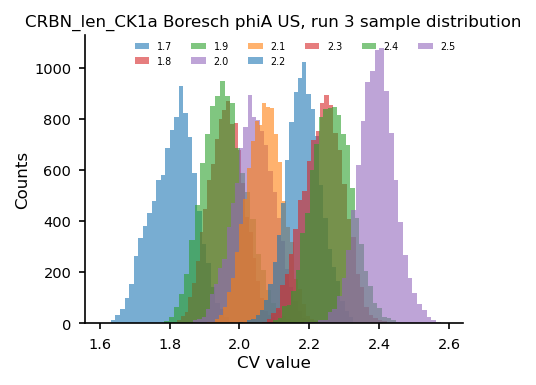

In [30]:
# Run cell

if stage == 'Boresch':
    equilibration = None # CV samples already truncated for Boresch US
else:
    equilibration = 'RED' # Use RED for separation and RMSD

generate_metafile(system, stage, dof, equilibration, run_number, plot=True)

### Calculating the overall delta G for a given system

Note that a test for sufficient sampling has been built into the function that calculates the total binding free energy. 

If the integrand covers less than 98% of the sampling range, a warning is displayed : ```WARNING : PMF for run X has insufficient sampling...```

Specify the system:

In [9]:
system = 'BRD4_IBG3_DCAF16'

In [10]:
# Run cell

dG, err, df_results = calc_total_DeltaG(system, plot_pmfs=False)
df_results.loc[len(df_results)] = ["Total", dG, err] 

with open(f"{system}/US/deltaG.txt", "w") as file:
    file.write(f"{system} ΔG_bind = {np.round(dG, 5)} ± {np.round(err, 5)} kcal/mol")

df_results.to_csv(f"{system}/US/deltaG_stages.csv", index=False)

print(f"\n{system} ΔG_bind = {np.round(dG, 1)} ± {np.round(err, 1)} kcal/mol\n")

Calculating separation contribution...


Applying RED: 100%|██████████| 34/34 [00:00<00:00, 75653.23it/s]
/home/btan/miniforge3/envs/openbiosim/lib/python3.11/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Calculating DCAF16_only RMSD contribution


Applying RED: 100%|██████████| 20/20 [00:00<00:00, 72881.04it/s]


Calculating BD1withDCAF16 RMSD contribution


...

Calculating BD1_only_bulk RMSD contribution


Applying RED: 100%|██████████| 14/14 [00:00<00:00, 65390.04it/s]


Calculating BD2_IBG3withBD1_bulk RMSD contribution


Applying RED: 100%|██████████| 14/14 [00:00<00:00, 62869.65it/s]


Calculating thetaA contribution...
Calculating thetaB contribution...
Calculating phiA contribution...
Calculating phiB contribution...
Calculating phiC contribution...

BRD4_IBG3_DCAF16 ΔG_bind = -15.4 ± 0.5 kcal/mol



### Visualising normalised integrands

Applying RED: 100%|██████████| 17/17 [00:00<00:00, 84783.79it/s]


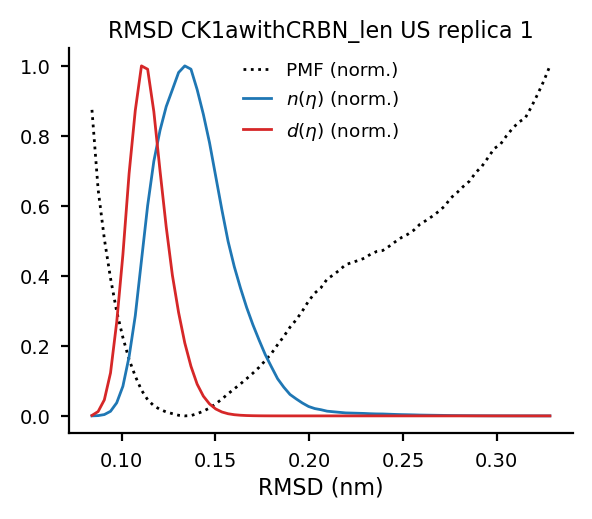

In [7]:
system = 'CRBN_len_CK1a'
stage = 'RMSD'
dof = 'CK1awithCRBN_len'
replica = 1

visualise_integrands(system, stage, dof, replica)

### Plotting the Boresch distributions during unrestrained MD

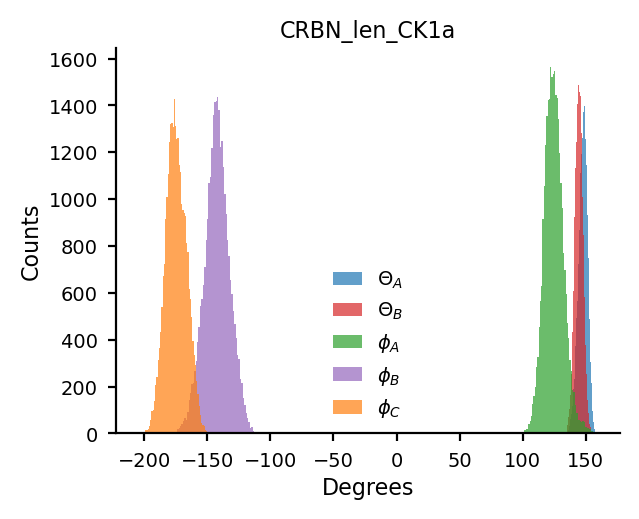

In [8]:
system = 'CRBN_len_CK1a'
plot_Boresch_distribution(system)